# Sequential Muscle Group Classification Models

This notebook implements three sequential models for muscle group classification using MediaPipe pose landmarks. The models will identify which muscle groups are being targeted in a workout sequence.

Key muscle groups typically include:
- Chest
- Back
- Shoulders
- Arms (Biceps/Triceps)
- Legs
- Core

In [1]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import pickle
from tensorflow.keras.utils import to_categorical


# Download the dataset
path = kagglehub.dataset_download("hasyimabdillah/workoutfitness-video")
print("Path to dataset files:", path)

# Import our custom modules
import sys
sys.path.append('..')
from mediapipe_handler.sequence_processor import SequenceProcessor
sys.path.append('../..')
from muscle_group_mapping import MUSCLE_GROUPS_7, MUSCLE_GROUP_LABELS_7

# Define muscle group mapping (7 groups, integer labels)
muscle_group_map = MUSCLE_GROUPS_7
muscle_group_labels_list = MUSCLE_GROUP_LABELS_7

Path to dataset files: /Users/yasinetawfeek/.cache/kagglehub/datasets/hasyimabdillah/workoutfitness-video/versions/5


In [8]:
import pickle
sequence_processor = SequenceProcessor(
    sequence_length=60,
    stride=5,
    target_fps=30)  # 3 seconds at 30fps

try:
    with open('../mediapipe_handler/sequences_labels_tuple.pkl', 'rb') as f:
        sequences, labels = pickle.load(f)
except FileNotFoundError:
    sequences, labels = sequence_processor.process_video_directory(path)

print(f"Total sequences processed: {len(sequences)}")

Total sequences processed: 21416


I0000 00:00:1759787945.392290 26192760 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4 Pro
W0000 00:00:1759787945.475560 27350058 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1759787945.484434 27350064 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [ ]:
# Handle both string workout names and integer indices, with fuzzy matching for common variants
workout_to_idx = {
    'barbell bicep curl': 0,
    'bench press': 1,
    'chest fly machine': 2,
    'deadlift': 3,
    'decline bench press': 4,
    'hammer curl': 5,
    'hip thrust': 6,
    'incline bench press': 7,
    'lat pulldown': 8,
    'lateral raises': 9,
    'leg extensions': 10,
    'leg raises': 11,
    'plank': 12,
    'pull up': 13,
    'push ups': 14,
    'romanian deadlift': 15,
    'russian twist': 16,
    'shoulder press': 17,
    'squat': 18,
    't bar row': 19,
    'tricep dips': 20,
    'tricep pushdown': 21,
    # Common variants
    'push-up': 14,
    'pushup': 14,
    'pushups': 14,
    'pull-up': 13,
    'pullup': 13,
    'pullups': 13,
    'squats': 18,
    'deadlifts': 3,
    'planks': 12,
    'lunges': 18, # fallback to legs
    'benchpress': 1,
    'lat-pulldown': 8,
    't-bar row': 19,
    'tricep-dips': 20,
    'tricep-pushdown': 21,
    'shoulder-press': 17,
    'hammer-curl': 5,
    'leg-raises': 11,
    'leg-extensions': 10,
    'chest-fly-machine': 2,
    'romanian-deadlift': 15,
    'russian-twist': 16,
    'incline-bench-press': 7,
    'decline-bench-press': 4,
    'barbell-bicep-curl': 0,
    'hip-thrust': 6,
    'lateral-raises': 9,
}

import difflib

def label_to_index(label):
    if isinstance(label, (int, np.integer)):
        return label
    if isinstance(label, str) or isinstance(label, np.str_):
        label = str(label).strip().lower().replace('_', ' ').replace('-', ' ')
        if label in workout_to_idx:
            return workout_to_idx[label]
        # Try fuzzy match
        close = difflib.get_close_matches(label, workout_to_idx.keys(), n=1, cutoff=0.8)
        if close:
            return workout_to_idx[close[0]]
        # Try removing plural
        if label.endswith('s') and label[:-1] in workout_to_idx:
            return workout_to_idx[label[:-1]]
        if label.isdigit():
            return int(label)
    raise ValueError(f"Unknown workout label: {label}")

workout_indices = np.array([label_to_index(l) for l in labels])
muscle_group_labels = np.array([muscle_group_map.get(idx, None) for idx in workout_indices])

# Filter out any samples where mapping failed (should not happen if mapping is complete)
valid_mask = muscle_group_labels != None
sequences = np.array(sequences)[valid_mask]
muscle_group_labels = muscle_group_labels[valid_mask].astype(int)

# Check if we have any samples after filtering
if len(sequences) == 0:
    raise ValueError("No valid samples found after mapping. Please check your dataset and mapping.")

# Convert to categorical (one-hot) encoding for 7 groups
y = to_categorical(muscle_group_labels, num_classes=len(muscle_group_labels_list))

# Split the data only if there are enough samples
if len(sequences) < 5:
    print(f"Warning: Only {len(sequences)} samples available. Skipping train/val/test split.")
    X_train = sequences
    y_train = y
    X_val = np.array([])
    y_val = np.array([])
    X_test = np.array([])
    y_test = np.array([])
else:
    X_train, X_test, y_train, y_test = train_test_split(
        sequences, y, test_size=0.2, random_state=42
)
    X_val, X_test, y_val, y_test = train_test_split(
        X_test, y_test, test_size=0.5, random_state=42
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)
print("Number of muscle groups:", len(muscle_group_labels_list))
print("Muscle groups:", muscle_group_labels_list)

I0000 00:00:1759787933.873075 26192760 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M4 Pro
W0000 00:00:1759787933.951273 27348895 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1759787933.962888 27348895 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Total sequences processed: 21416
Training set shape: (17132, 60, 36)
Validation set shape: (2142, 60, 36)
Test set shape: (2142, 60, 36)
Number of muscle groups: 7
Muscle groups: ['biceps', 'chest', 'back', 'legs', 'shoulders', 'core', 'triceps']


## Model Definitions

We'll create three models similar to the workout classifier but adapted for multi-label classification:

In [3]:
# Define models for single-label (categorical) classification (7 muscle groups)
def create_lstm_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # softmax for single-label
    ])
    return model

def create_gru_model(input_shape, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.GRU(128, return_sequences=True, input_shape=input_shape),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.GRU(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')  # softmax for single-label
    ])
    return model

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = tf.keras.layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates
    pos_encoding = np.zeros((seq_len, d_model))
    pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.constant(pos_encoding, dtype=tf.float32)

def create_transformer_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)
    pos_encoding = positional_encoding(input_shape[0], input_shape[1])
    x = inputs + pos_encoding
    transformer_block1 = TransformerBlock(input_shape[1], 8, 32)
    transformer_block2 = TransformerBlock(input_shape[1], 8, 32)
    x = transformer_block1(x)
    x = transformer_block2(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs)

# Create and compile models
lstm_model = create_lstm_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=len(muscle_group_labels_list)
    )

gru_model = create_gru_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=len(muscle_group_labels_list)
    )

transformer_model = create_transformer_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    num_classes=len(muscle_group_labels_list)
    )

# Compile models with categorical crossentropy for single-label classification
for model in [lstm_model, gru_model, transformer_model]:
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

/opt/anaconda3/envs/mediapipe/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Model Training

Train all three models with early stopping:

In [4]:
# Train models
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

histories = {}
for name, model in [('lstm', lstm_model), ('gru', gru_model), ('transformer', transformer_model)]:
    print(f"\nTraining {name.upper()} model:")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping]
    )
    histories[name] = history

# Evaluate models
for name, model in [('lstm', lstm_model), ('gru', gru_model), ('transformer', transformer_model)]:
    scores = model.evaluate(X_test, y_test)
    print(f"\n{name.upper()} Test Results:")
    for metric, score in zip(model.metrics_names, scores):
        print(f"{metric}: {score:.4f}")

# Save models
lstm_model.save('../../models/muscle_group_classifier/lstm_model.keras')
gru_model.save('../../models/muscle_group_classifier/gru_model.keras')
transformer_model.save('../../models/muscle_group_classifier/transformer_model.keras')

# Save muscle group label list for inference
import pickle
with open('../../models/muscle_group_classifier/muscle_group_labels_list.pkl', 'wb') as f:
    pickle.dump(muscle_group_labels_list, f)


Training LSTM model:
Epoch 1/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.5004 - loss: 1.3411 - val_accuracy: 0.7306 - val_loss: 0.7763
Epoch 2/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.7611 - loss: 0.7124 - val_accuracy: 0.8553 - val_loss: 0.4408
Epoch 3/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.8455 - loss: 0.4926 - val_accuracy: 0.8623 - val_loss: 0.4751
Epoch 4/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.8024 - loss: 0.6088 - val_accuracy: 0.9150 - val_loss: 0.2769
Epoch 5/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.9000 - loss: 0.3262 - val_accuracy: 0.9332 - val_loss: 0.2301
Epoch 6/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.9206 - loss: 0.2614 - val_accuracy: 0.8772 - val_loss: 0.3628
Epoch 7/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.9181 - loss: 0.2495 - val_accuracy: 0.8735 - val_loss: 0.3998
Epoch 8/50
536/536 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.


LSTM Confusion Matrix and Classification Report:
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


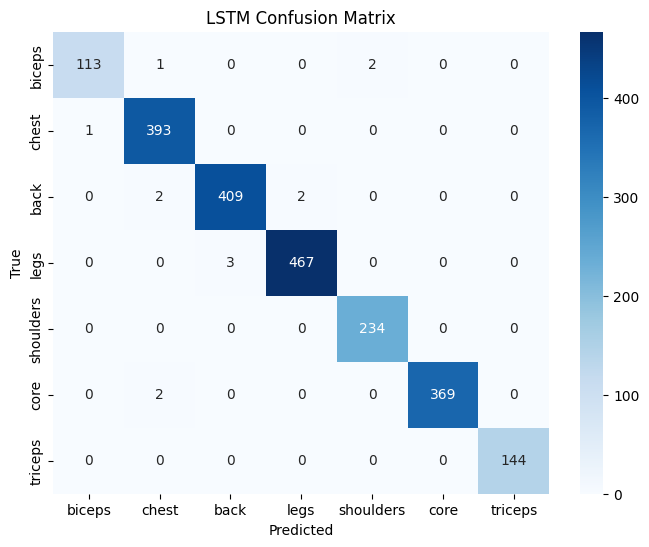

              precision    recall  f1-score   support

      biceps       0.99      0.97      0.98       116
       chest       0.99      1.00      0.99       394
        back       0.99      0.99      0.99       413
        legs       1.00      0.99      0.99       470
   shoulders       0.99      1.00      1.00       234
        core       1.00      0.99      1.00       371
     triceps       1.00      1.00      1.00       144

    accuracy                           0.99      2142
   macro avg       0.99      0.99      0.99      2142
weighted avg       0.99      0.99      0.99      2142


GRU Confusion Matrix and Classification Report:
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


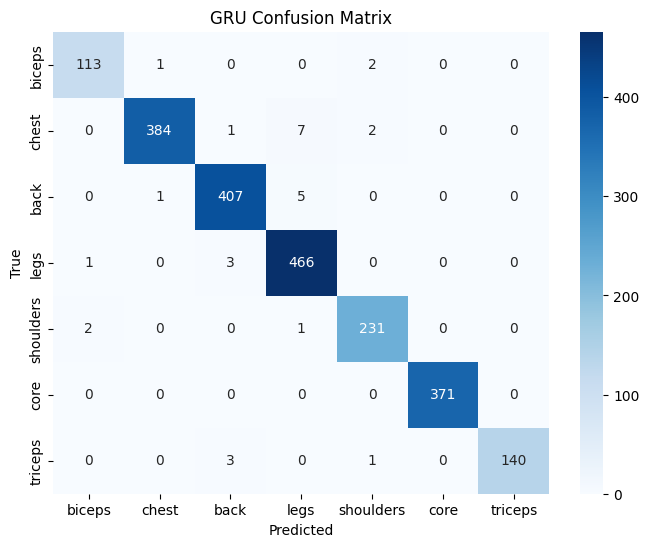

              precision    recall  f1-score   support

      biceps       0.97      0.97      0.97       116
       chest       0.99      0.97      0.98       394
        back       0.98      0.99      0.98       413
        legs       0.97      0.99      0.98       470
   shoulders       0.98      0.99      0.98       234
        core       1.00      1.00      1.00       371
     triceps       1.00      0.97      0.99       144

    accuracy                           0.99      2142
   macro avg       0.99      0.98      0.98      2142
weighted avg       0.99      0.99      0.99      2142


TRANSFORMER Confusion Matrix and Classification Report:
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


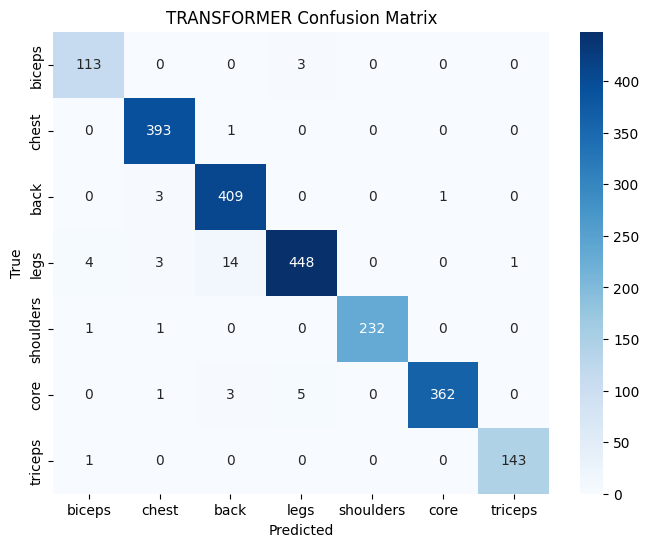

              precision    recall  f1-score   support

      biceps       0.95      0.97      0.96       116
       chest       0.98      1.00      0.99       394
        back       0.96      0.99      0.97       413
        legs       0.98      0.95      0.97       470
   shoulders       1.00      0.99      1.00       234
        core       1.00      0.98      0.99       371
     triceps       0.99      0.99      0.99       144

    accuracy                           0.98      2142
   macro avg       0.98      0.98      0.98      2142
weighted avg       0.98      0.98      0.98      2142



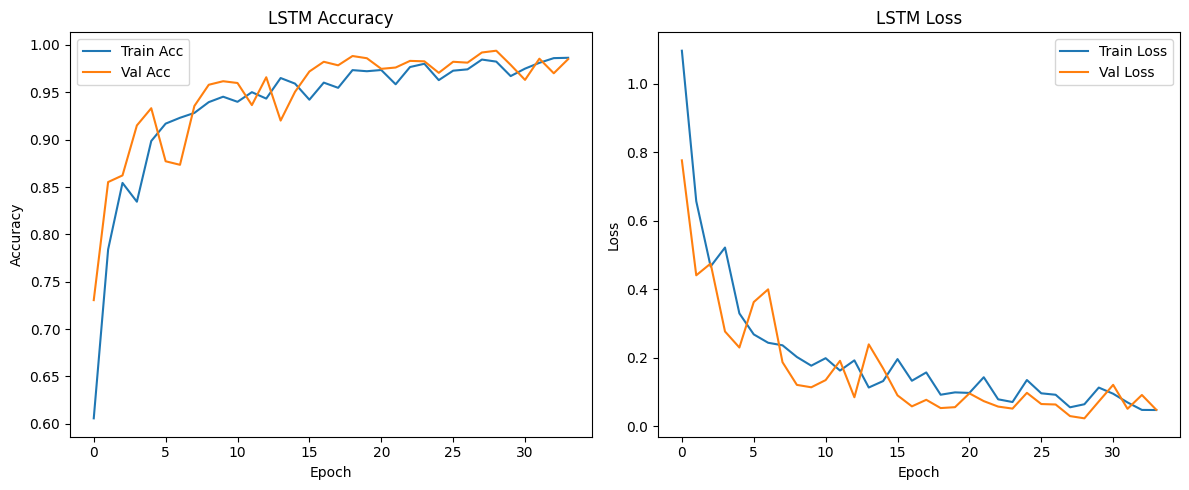

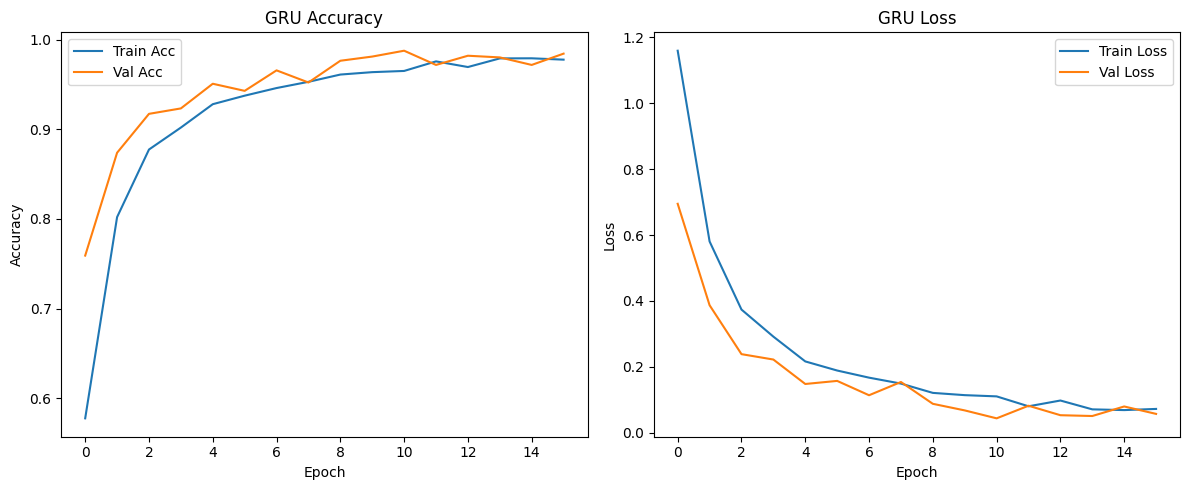

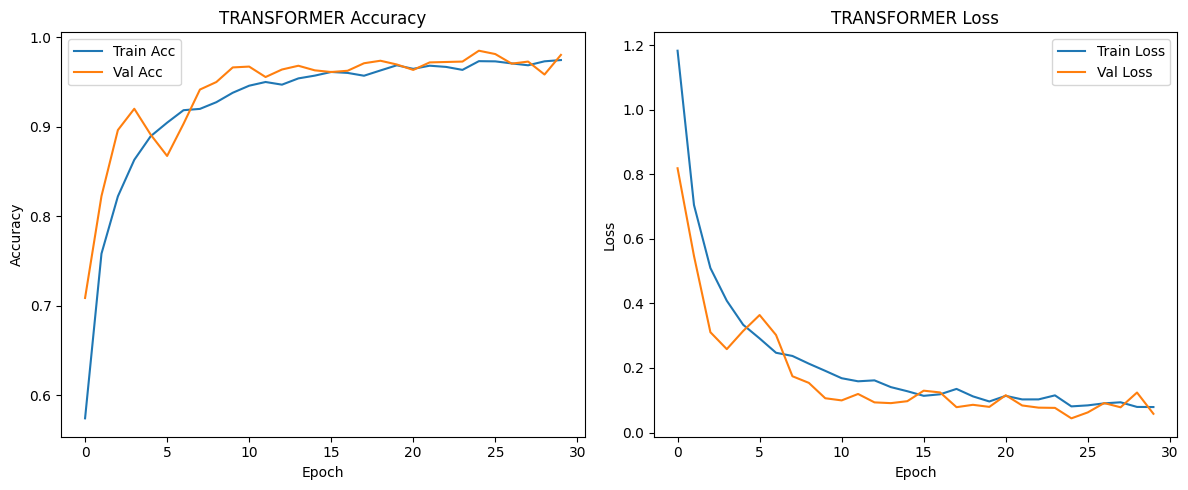

In [6]:
# --- Evaluation: Confusion Matrix and Classification Report ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

# Evaluate each model on test set
for name, model in [('lstm', lstm_model), ('gru', gru_model), ('transformer', transformer_model)]:
    if len(X_test) == 0:
        print(f"No test data for {name.upper()} model.")
        continue
    print(f"\n{name.upper()} Confusion Matrix and Classification Report:")
    y_pred = model.predict(X_test)
    y_pred_classes = y_pred.argmax(axis=1)
    y_true_classes = y_test.argmax(axis=1)
    plot_confusion_matrix(y_true_classes, y_pred_classes, muscle_group_labels_list, f'{name.upper()} Confusion Matrix')
    print(classification_report(y_true_classes, y_pred_classes, target_names=muscle_group_labels_list))

# --- Plot Model Performance Over Training Time ---
def plot_training_history(history, model_name):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

for name, history in histories.items():
    plot_training_history(history, name.upper())